# AMSR2/AMSR-E Data Access
This tutorial is designed to access snow water equivalent (SWE) data from the Advanced Microwave Scanning Radiometer missions (AMSR2/-E).

In [1]:
import earthaccess
import geopandas as gpd
import glob
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import h5py
import numpy as np
import datetime

The AMSR SWE data is available through NSIDC, so we are capable of streaming it directly through the cloud. Let's start with a simple example using only a single file.

According to its NSIDC webpage (https://nsidc.org/data/au_dysno/versions/1), the short name for the AMSR SWE product is `AU_DySno`. We will look at an image that includes Fairbanks, AK during the SnowEx campaign in March 2023.

In [2]:
# Authenticate with earthaccess
earthaccess.login()

In [3]:
# Convert Fairbanks geoJSON to earthaccess-friendly format.
fairbanks = gpd.read_file("/home/jovyan/snow-observations-cookbook/notebooks/data/cffl_lidar_box.geojson")
fairbanks.to_crs("EPSG:4326", inplace=True)
minx, miny, maxx, maxy = fairbanks.total_bounds

# Run the earthaccess query
results = earthaccess.search_data(
    short_name='AU_DySno',
    bounding_box=(minx, miny, maxx, maxy),
    temporal=("2023-03-01", "2023-03-31"),
    count=10
)

In [5]:
display(results[0])

Collection: {'EntryTitle': 'AMSR-E/AMSR2 Unified L3 Global Daily 25 km EASE-Grid Snow Water Equivalent V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 89.24, 'SouthBoundingCoordinate': -89.24}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-02-28T00:34:25.994Z', 'EndingDateTime': '2023-03-01T00:28:07.264Z'}}
Size(MB): 9.97532
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/02/28/AMSR_U2_L3_DailySnow_B02_20230228.he5', 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_DySno/1/2023/02/28/AMSR_U2_L3_DailySnow_B02_20230228.ph']

In [4]:
# Stream the data directly into memory
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/20 [00:00<?, ?it/s]

The search results return two files per granule: one containing the primary data (coordinates, SWE, etc.) in HDF-EOS5 (.he5) format and an ancillary text file in .ph format. For the purposes of this tutorial, we will only be looking at the HE5 file.

Each variable in the HE5 file is in gridded format $(y, x)$, and has filler values that could cause problems when plotting. We will therefore start by loading the data into Numpy arrays, then masking out filler values.

In [5]:
with h5py.File(files[0], 'r') as f:
    # Read the datasets
    lon = f['HDFEOS/GRIDS/Northern Hemisphere/lon'][:]
    lat = f['HDFEOS/GRIDS/Northern Hemisphere/lat'][:]
    swe = f['HDFEOS/GRIDS/Northern Hemisphere/Data Fields/SWE_NorthernDaily'][:]

# Create masks for valid coordinates - this is for the SWE data!
valid_mask = np.isfinite(lon) & np.isfinite(lat)

# Apply mask to coordinates - replace non-finite with a dummy value
# or create a version with only finite values
lon_clean = np.where(np.isfinite(lon), lon, 0)
lat_clean = np.where(np.isfinite(lat), lat, 0)

# Mask SWE data where coordinates are invalid
swe_masked = np.where(valid_mask, swe, np.nan)
swe_masked = np.where((swe_masked<=240)&(swe_masked>0), swe_masked, np.nan)

Now that the data is masked, we can construct a DataArray with the latitude, longitude, and SWE data. Note that, for plotting, we will need to specify the lon/lat variables to be our x/y coordinates, otherwise they will not show up correctly.

In [6]:
da = xr.DataArray(
    swe_masked,
    dims=['y', 'x'],
    coords={
        'lon': (['y', 'x'], lon_clean),
        'lat': (['y', 'x'], lat_clean)
    },
    attrs={
        'long_name': 'Snow Water Equivalent',
        'units': 'mm',
        'projection': 'EPSG:3408'
    },
    name='SWE'
)

(55.0, 75.0)

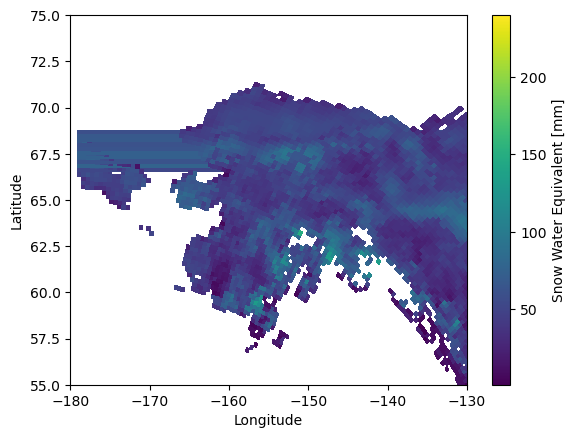

In [7]:
# Plot a map of AMSR-2 SWE over Alaska
fig, ax = plt.subplots()
da.plot(x='lon', y='lat')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-180, -130)
ax.set_ylim(55, 75)

## Working With Multiple AMSR-2 Files

We were able to obtain a map of AMSR-2 SWE data fairly easily. However, since we have 10 files with our query, let's see if we can generate two additional figures with the data: (1) a time series of spatially-averaged SWE, and (2) a map of time-averaged SWE.

For cleanliness, we are going to take the pre-processing code from above and make it into a function.

In [29]:
files[0].full_name.split('.')[-1]

'he5'

In [36]:
# Function to identify coordinates and SWE data
def assign_and_grid(amsr2_file):
    with h5py.File(amsr2_file,'r') as f:
        # Read the datasets
        lon = f['HDFEOS/GRIDS/Northern Hemisphere/lon'][:]
        lat = f['HDFEOS/GRIDS/Northern Hemisphere/lat'][:]
        swe = f['HDFEOS/GRIDS/Northern Hemisphere/Data Fields/SWE_NorthernDaily'][:]

        # Create masks for valid coordinates - this is for the SWE data!
        valid_mask = np.isfinite(lon) & np.isfinite(lat)
        
        # Apply mask to coordinates - replace non-finite with a dummy value
        # or create a version with only finite values
        lon_clean = np.where(np.isfinite(lon), lon, 0)
        lat_clean = np.where(np.isfinite(lat), lat, 0)
        
        # Mask SWE data where coordinates are invalid
        swe_masked = np.where(valid_mask, swe, np.nan)
        swe_masked = np.where((swe_masked<=240)&(swe_masked>0), swe_masked, np.nan)

        # Set up DataArray
        da = xr.DataArray(
            swe_masked,
            dims=['y', 'x'],
            coords={
                'lon': (['y', 'x'], lon_clean),
                'lat': (['y', 'x'], lat_clean)
            },
            attrs={
                'long_name': 'Snow Water Equivalent',
                'units': 'mm',
                'projection': 'EPSG:3408'
            },
            name='SWE'
        )

        return da

def generate_date(file):
    # Get YYYYMMDD string
    yyyymmdd = file.full_name.split('/')[-1].split('_')[-1].split('.')[0]

    # Convert to datetime format
    dt = np.datetime64(datetime.date(int(yyyymmdd[:4]),int(yyyymmdd[4:6]),int(yyyymmdd[6:])))

    return dt

In [37]:
# Create empty lists of overpass dates and data
date_list = []
da_concat = []

# Loop through files for loading and processing
for fCount,file in enumerate(files):
    if file.full_name.split('.')[-1] == 'he5':
        #print(file)
        
        try:
            # Load and pre-process AMSR-2 data
            da = assign_and_grid(file)
    
            # Concatenate to date and data lists
            if len(da.values[~np.isnan(da.values)]) > 0:
                dt = generate_date(file)
                print(dt)
    
                date_list.append(dt)
                da_concat.append(da)
        except:
            print('Error: Unable to process file.')
    
# Create Data Array of all AMSR-2 files
da_concat = xr.concat(da_concat,dim="time")

# Add time as a dimension
da_concat['time'] = ('time', date_list)

2023-02-28
2023-03-01
2023-03-02
2023-03-03
2023-03-04
2023-03-05
2023-03-06
2023-03-07
2023-03-08
2023-03-09


In [51]:
# Group by unique times
grouped = da_concat.groupby('time')

# Apply nanmean to each group, keeping it as an xarray.DataArray
da_concat = grouped.map(
    lambda group: xr.DataArray(
        np.nanmean(group, axis=0),  # Compute nanmean along the time axis
        dims=group.dims[1:],       # Keep the original spatial dimensions
        coords={dim: group.coords[dim] for dim in group.dims[1:]}  # Preserve coordinates
    )
)

da_concat.rio.write_crs("EPSG:3408", inplace=True)

/tmp/ipykernel_123/1563219848.py:7: RuntimeWarning: Mean of empty slice
  np.nanmean(group, axis=0),  # Compute nanmean along the time axis


<xarray.DataArray (time: 10, y: 721, x: 721)> Size: 42MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time         (time) datetime64[s] 80B 2023-02-28 2023-03-01 ... 2023-03-09
  * y            (y) int64 6kB 0 1 2 3 4 5 6 7 ... 714 715 716 717 718 719 720
  * x            (x) int64 6kB 0 1 2 3 4 5 6 7 ... 714 715 716 717 718 719 720
    spatial_ref  int64 8B 0

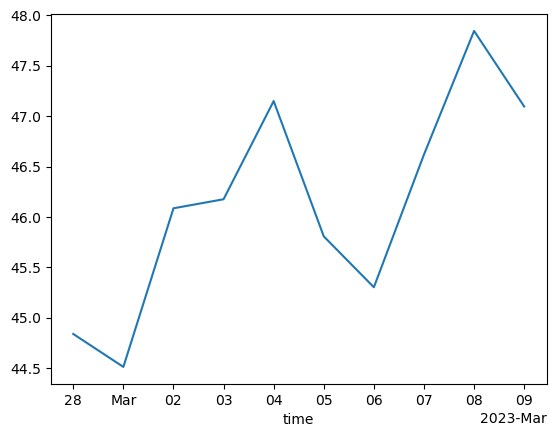

In [41]:
# Plot spatially-averaged time series of snow cover
da_concat.mean(dim=('x','y')).plot()

Text(0.5, 1.0, 'AMSR-2 SWE, 10-day mean')

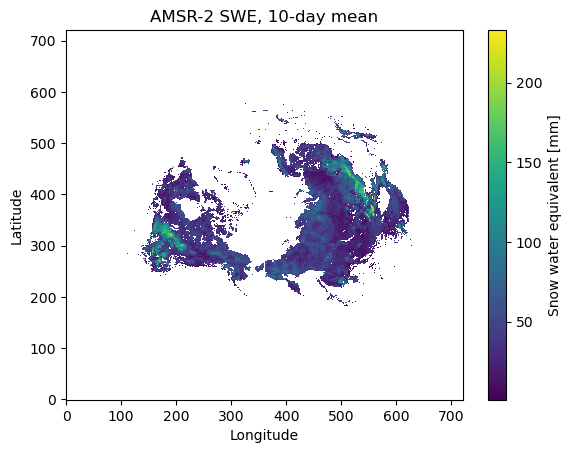

In [55]:
# Plot map of time-averaged snow cover
fig, ax = plt.subplots()
da_concat.mean(dim='time').plot(ax=ax, cbar_kwargs={'label': "Snow water equivalent [mm]"})
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"AMSR-2 SWE, 10-day mean")
#ax.set_xlim(-180, -130)
#ax.set_ylim(55, 75)

## Obtaining AMSR-2 Brightness Temperature

Alternatively, a data user may be interested in the brightness temperature product from AMSR-2, which allows for more customized options.

Like the SWE product, the brightness temperature product is available through NSIDC, using either the short name (`AU_Land`) or the data DOI (`10.5067/IKQ0G7ODMLC7`). We'll follow an example that loads multiple AMSR-2 files.

In [3]:
# Convert Fairbanks geoJSON to earthaccess-friendly format.
fairbanks = gpd.read_file("/home/jovyan/snow-observations-cookbook/notebooks/data/cffl_lidar_box.geojson")
fairbanks.to_crs("EPSG:4326", inplace=True)
#minx, miny, maxx, maxy = fairbanks.total_bounds
minx, miny, maxx, maxy = -124.7, 31, -103, 49

# Run the earthaccess query
results = earthaccess.search_data(
    short_name='AU_SI25',
    bounding_box=(minx, miny, maxx, maxy),
    temporal=("2023-03-01", "2023-03-31"),
    count=10
)

In [13]:
display(results[1])

Collection: {'EntryTitle': 'AMSR-E/AMSR2 Unified L2B Half-Orbit 25 km EASE-Grid Surface Soil Moisture V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Orbit': {'AscendingCrossing': 65.05, 'StartLatitude': 81.8, 'StartDirection': 'D', 'EndLatitude': -81.8, 'EndDirection': 'D'}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-03-01T09:32:04.146Z', 'EndingDateTime': '2023-03-01T10:21:26.363Z'}}
Size(MB): 2.81155
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Land/1/2023/03/01/AMSR_U2_L2_Land_B02_202303010932_D.he5', 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Land/1/2023/03/01/AMSR_U2_L2_Land_B02_202303010932_D.ph']

In [4]:
# Stream the data directly into memory
files = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/20 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/20 [00:00<?, ?it/s]

Note that the below functions are very similar to the SWE data example, only accessing brightness temperature instead.

In [5]:
data_dir = 'HDFEOS/GRIDS/NpPolarGrid25km'

def assign_and_grid(amsr2_file):
    with h5py.File(amsr2_file,'r') as f:
        # Read the datasets
        lon = f[f'{data_dir}/lon'][:]
        lat = f[f'{data_dir}/lat'][:]
        tbv18 = f[f'{data_dir}/Data Fields/SI_25km_NH_18V_DSC'][:]
        tbv36 = f[f'{data_dir}/Data Fields/SI_25km_NH_36V_DSC'][:]

        # Get shape of gridded data
        num_y_points, num_x_points = tbv18.shape

        # Create coordinate arrays
        y_coords = np.arange(num_y_points)
        x_coords = np.arange(num_x_points)

        # Set up the xarray Dataset
        ds = xr.Dataset(
            data_vars={
                "tbv18": (["y", "x"], tbv18, {
                    "units": "K",
                    "long_name": "Brightness Temperature 18 GHz V-pol",
                }),
                "tbv36": (["y", "x"], tbv36, {
                    "units": "K",
                    "long_name": "Brightness Temperature 36 GHz V-pol",
                }),
            },
            coords={
                "lon": (["y", "x"], lon),
                "lat": (["y", "x"], lat),
            },
            attrs={
                "description": "AMSR-2 Gridded Brightness Temperature, 18/36 GHz",
                "projection": "EPSG:3411",
            },
        )

        return ds

def generate_date(file):
    # Get YYYYMMDD string
    yyyymmdd = file.full_name.split('/')[-1].split('_')[-1].split('.')[0]

    # Convert to datetime format
    dt = np.datetime64(datetime.date(int(yyyymmdd[:4]),int(yyyymmdd[4:6]),int(yyyymmdd[6:])))

    return dt

In [6]:
# Create empty lists of overpass dates and data
date_list = []
ds_concat = []

# Loop through files for loading and processing
for fCount,file in enumerate(files):
    if file.full_name.split('.')[-1] == 'he5':
        #print(file)
        
        try:
            # Load and pre-process AMSR-2 data
            ds = assign_and_grid(file)
            #print('File loaded and gridded!')
    
            # Concatenate to date and data lists
            #if len(ds.values[~np.isnan(ds.values)]) > 0:
            dt = generate_date(file)
            #print(dt)

            date_list.append(dt)
            ds_concat.append(ds)
        except Exception as e:
            print(f"Error Type: {type(e).__name__}")
    
# Create Data Array of all AMSR-2 files
ds_concat = xr.concat(ds_concat,dim="time")

# Add time as a dimension
ds_concat['time'] = ('time', date_list)

# Assign CRS
ds_concat = ds_concat.rio.write_crs("EPSG:3411")

# Apply weighting factor to brightness temperatures
ds_concat['tbv18'] = ds_concat['tbv18']/10
ds_concat['tbv36'] = ds_concat['tbv36']/10

In [7]:
ds_concat

<xarray.Dataset> Size: 23MB
Dimensions:      (time: 10, y: 448, x: 304)
Coordinates:
  * time         (time) datetime64[s] 80B 2023-02-28 2023-03-01 ... 2023-03-09
    lon          (y, x) float32 545kB 168.3 168.1 168.0 ... -10.36 -10.18 -9.999
    lat          (y, x) float32 545kB 31.1 31.2 31.3 31.39 ... 34.68 34.58 34.47
    spatial_ref  int64 8B 0
Dimensions without coordinates: y, x
Data variables:
    tbv18        (time, y, x) float64 11MB 0.0 0.0 0.0 0.0 ... 196.3 195.2 194.9
    tbv36        (time, y, x) float64 11MB 0.0 0.0 0.0 0.0 ... 216.7 216.0 215.6
Attributes:
    description:  AMSR-2 Gridded Brightness Temperature, 18/36 GHz
    projection:   EPSG:3411

Text(0.5, 1.0, 'Northern Hemisphere Tb at 18GHz')

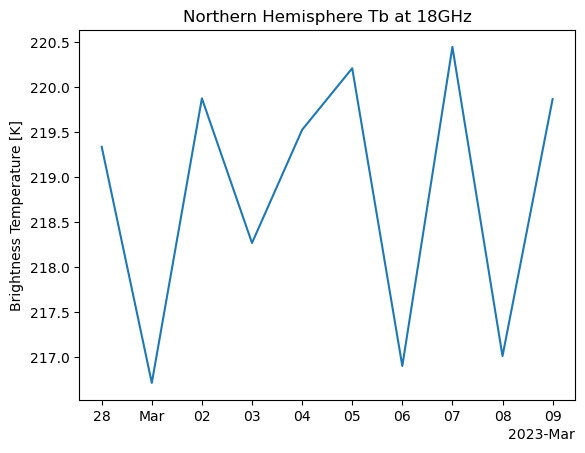

In [15]:
# Spatially-averaged Tb at 18 GHz
fig, ax = plt.subplots()
ds_concat['tbv18'].mean(dim=('x','y')).plot(ax=ax)
ax.set_xlabel(' ')
ax.set_ylabel('Brightness Temperature [K]')
ax.set_title('Northern Hemisphere Tb at 18GHz')

Text(0.5, 1.0, 'AMSR-2 18 GHz Tb, 10-day mean')

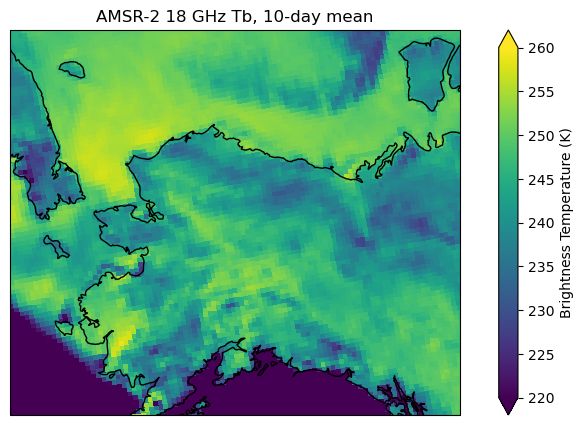

In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 5))
# Use NorthPolarStereo for Arctic plots
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-145))
ax.set_extent([-170, -130, 58, 75], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ds_concat.tbv18.mean(dim='time').plot.pcolormesh(
    ax=ax,
    x='lon',
    y='lat',
    vmin=220,
    vmax=260,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Brightness Temperature (K)'}
)
ax.set_title('AMSR-2 18 GHz Tb, 10-day mean')